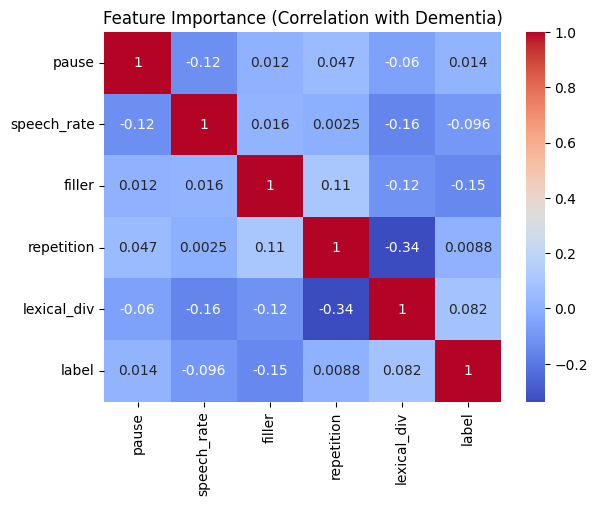

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# load features
import pickle
with open("/content/drive/MyDrive/final_features.pkl", "rb") as f:
    data = pickle.load(f)

# build dataframe
df = pd.DataFrame({
    "pause": [d["features"]["pause_count"] for d in data],
    "speech_rate": [d["features"]["speech_rate"] for d in data],
    "filler": [d["features"]["filler_count"] for d in data],
    "repetition": [d["features"]["repetition"] for d in data],
    "lexical_div": [d["features"]["lexical_diversity"] for d in data],
    "label": [d["label"] for d in data]
})

# correlation heatmap
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Importance (Correlation with Dementia)")
plt.show()

In [14]:
import numpy as np

dementia = df[df["label"] == 1]
control = df[df["label"] == 0]

print("Avg pause (Dementia):", dementia["pause"].mean())
print("Avg pause (Control):", control["pause"].mean())

print("Avg speech rate (Dementia):", dementia["speech_rate"].mean())
print("Avg speech rate (Control):", control["speech_rate"].mean())

Avg pause (Dementia): 0.7535601265822784
Avg pause (Control): 0.7193460490463215
Avg speech rate (Dementia): 171.25069933247624
Avg speech rate (Control): 226.97279822364655


/tmp/ipykernel_4643/2195256168.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


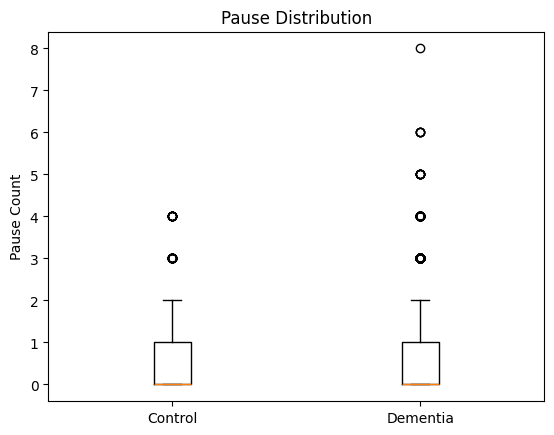

In [15]:
plt.boxplot(
    [control["pause"], dementia["pause"]],
    labels=["Control", "Dementia"]
)
plt.title("Pause Distribution")
plt.ylabel("Pause Count")
plt.show()

In [16]:
def get_task(path):
    path = path.lower()
    if "cookie" in path:
        return "cookie"
    elif "fluency" in path:
        return "fluency"
    else:
        return "sentence"

tasks = [get_task(d["audio"]) for d in data]
df["task"] = tasks

print(df.groupby("task")[["pause", "speech_rate"]].mean())

             pause  speech_rate
task                           
cookie    0.760486   216.766563
fluency   0.808924   109.402401
sentence  0.639300   198.278743
